In [ ]:
!pip install fredapi pandas matplotlib scikit-learn plotly -q


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

# Connect to FRED
fred = Fred(api_key='Your-Key')

print("Connected to FRED successfully!")

Connected to FRED successfully!


In [ ]:
# Treasury yields across different maturities
maturities = {
    '3-Month': 'TB3MS',
    '1-Year': 'GS1',
    '2-Year': 'GS2',
    '5-Year': 'GS5',
    '10-Year': 'GS10',
    '30-Year': 'GS30'
}

# Pull data from 2018 to today
yields = pd.DataFrame()

for name, series_id in maturities.items():
    data = fred.get_series(series_id, observation_start='2018-01-01')
    yields[name] = data

# Drop missing values
yields = yields.dropna()

print(f"Data shape: {yields.shape}")
print(f"Date range: {yields.index[0]} to {yields.index[-1]}")
print(f"\nLatest yield curve:")
print(yields.tail(1).T)

Data shape: (98, 6)
Date range: 2018-01-01 00:00:00 to 2026-02-01 00:00:00

Latest yield curve:
         2026-02-01
3-Month        3.60
1-Year         3.48
2-Year         3.47
5-Year         3.68
10-Year        4.13
30-Year        4.76


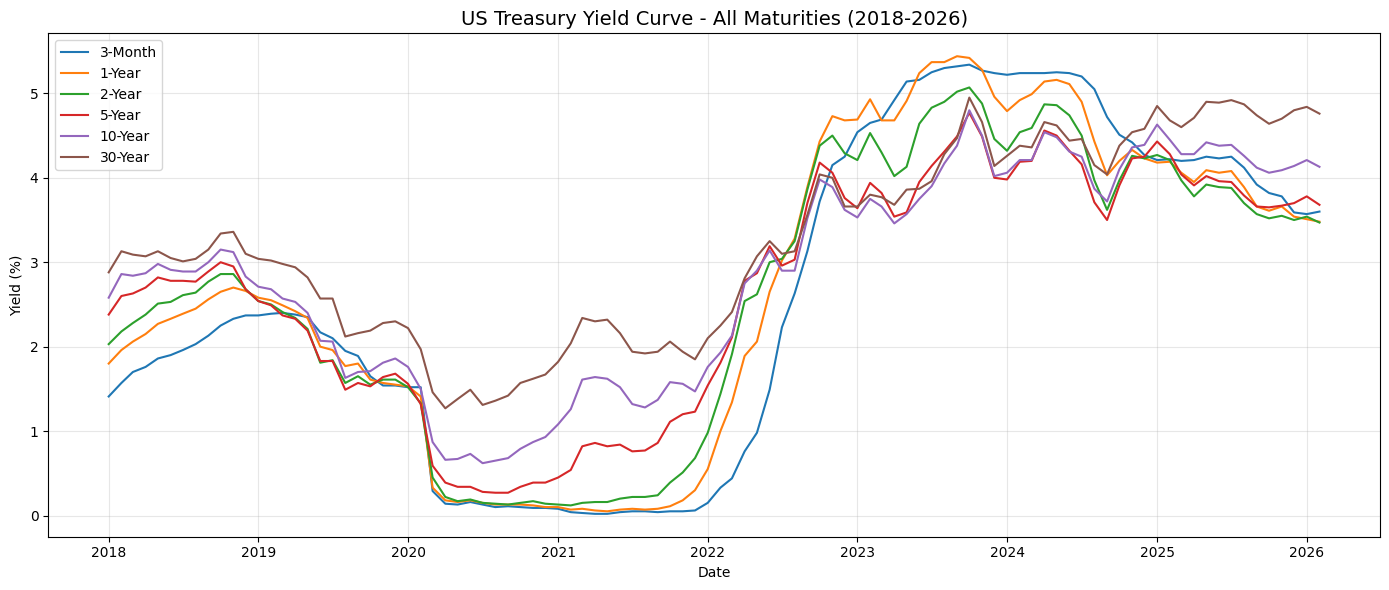

Chart saved!


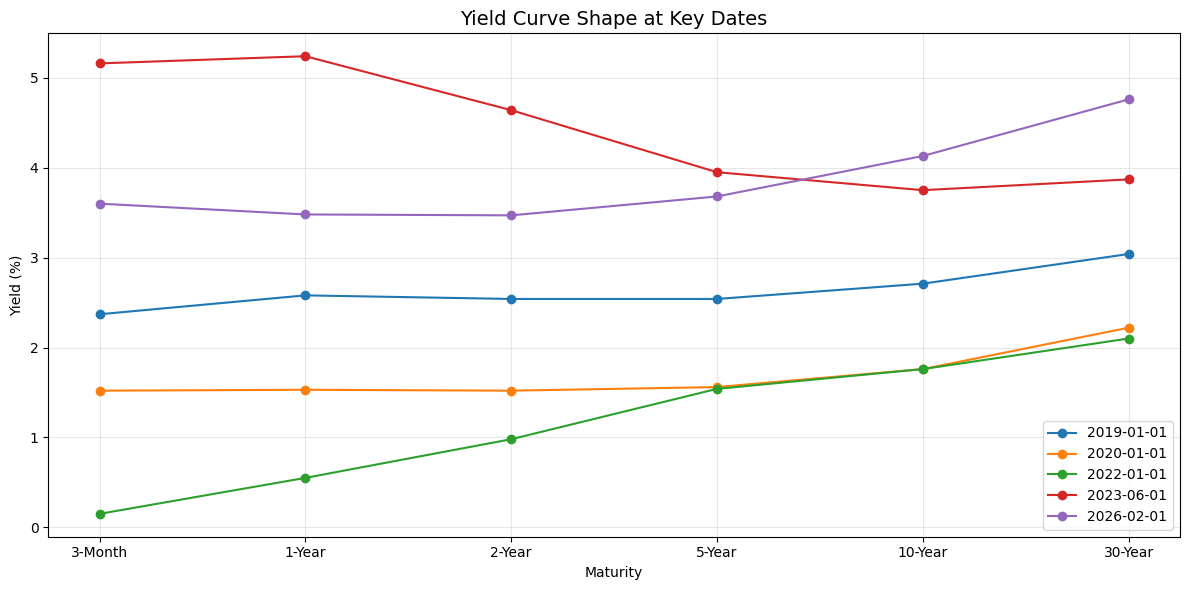

Charts saved!


In [ ]:
# Plot 1 - All yields over time
plt.figure(figsize=(14, 6))
for col in yields.columns:
    plt.plot(yields.index, yields[col], label=col)

plt.title('US Treasury Yield Curve - All Maturities (2018-2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yields_over_time.png', dpi=150)
plt.show()
print("Chart saved!")

# Plot 2 - Yield curve shape at key dates
plt.figure(figsize=(12, 6))
key_dates = ['2019-01-01', '2020-01-01', '2022-01-01', '2023-06-01', '2026-02-01']
maturity_order = ['3-Month', '1-Year', '2-Year', '5-Year', '10-Year', '30-Year']

for date in key_dates:
    closest = yields.index[yields.index.searchsorted(date)]
    plt.plot(maturity_order, yields.loc[closest, maturity_order].values,
             marker='o', label=str(closest.date()))

plt.title('Yield Curve Shape at Key Dates', fontsize=14)
plt.xlabel('Maturity')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yield_curve_shape.png', dpi=150)
plt.show()
print("Charts saved!")

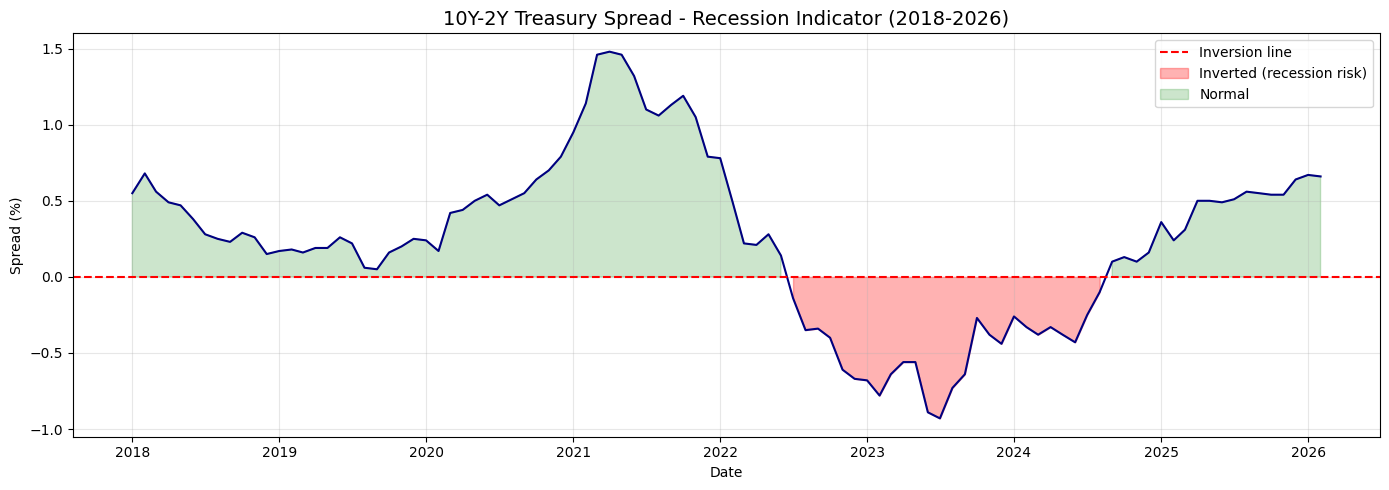

Spread chart saved!


In [ ]:
# 10Y-2Y spread - most watched recession indicator
yields['Spread_10Y_2Y'] = yields['10-Year'] - yields['2-Year']

plt.figure(figsize=(14, 5))
plt.plot(yields.index, yields['Spread_10Y_2Y'], color='navy', linewidth=1.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Inversion line')
plt.fill_between(yields.index, yields['Spread_10Y_2Y'], 0,
                 where=(yields['Spread_10Y_2Y'] < 0),
                 color='red', alpha=0.3, label='Inverted (recession risk)')
plt.fill_between(yields.index, yields['Spread_10Y_2Y'], 0,
                 where=(yields['Spread_10Y_2Y'] >= 0),
                 color='green', alpha=0.2, label='Normal')

plt.title('10Y-2Y Treasury Spread - Recession Indicator (2018-2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Spread (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('spread_10y_2y.png', dpi=150)
plt.show()
print("Spread chart saved!")

In [ ]:
# Feature engineering for forecasting
df = yields.copy()

# Lag features
df['10Y_lag1'] = df['10-Year'].shift(1)
df['10Y_lag3'] = df['10-Year'].shift(3)
df['10Y_lag6'] = df['10-Year'].shift(6)

# Rolling statistics
df['10Y_rolling_mean_6'] = df['10-Year'].rolling(6).mean()
df['10Y_rolling_std_6'] = df['10-Year'].rolling(6).std()

# Spread features
df['Spread_10Y_2Y'] = df['10-Year'] - df['2-Year']
df['Spread_10Y_3M'] = df['10-Year'] - df['3-Month']

# Drop NaN rows created by lags
df = df.dropna()

print(f"Features shape: {df.shape}")
print(f"\nFeature columns: {list(df.columns)}")

Features shape: (92, 13)

Feature columns: ['3-Month', '1-Year', '2-Year', '5-Year', '10-Year', '30-Year', 'Spread_10Y_2Y', '10Y_lag1', '10Y_lag3', '10Y_lag6', '10Y_rolling_mean_6', '10Y_rolling_std_6', 'Spread_10Y_3M']


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features and target
feature_cols = ['3-Month', '1-Year', '2-Year', '5-Year', '30-Year',
                'Spread_10Y_2Y', 'Spread_10Y_3M',
                '10Y_lag1', '10Y_lag3', '10Y_lag6',
                '10Y_rolling_mean_6', '10Y_rolling_std_6']

X = df[feature_cols]
y = df['10-Year']

# Train/test split - keep time order!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Performance:")
print(f"MAE:  {mae:.4f}%")
print(f"RMSE: {rmse:.4f}%")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Model Performance:
MAE:  0.2636%
RMSE: 0.2838%
Train size: 73 | Test size: 19


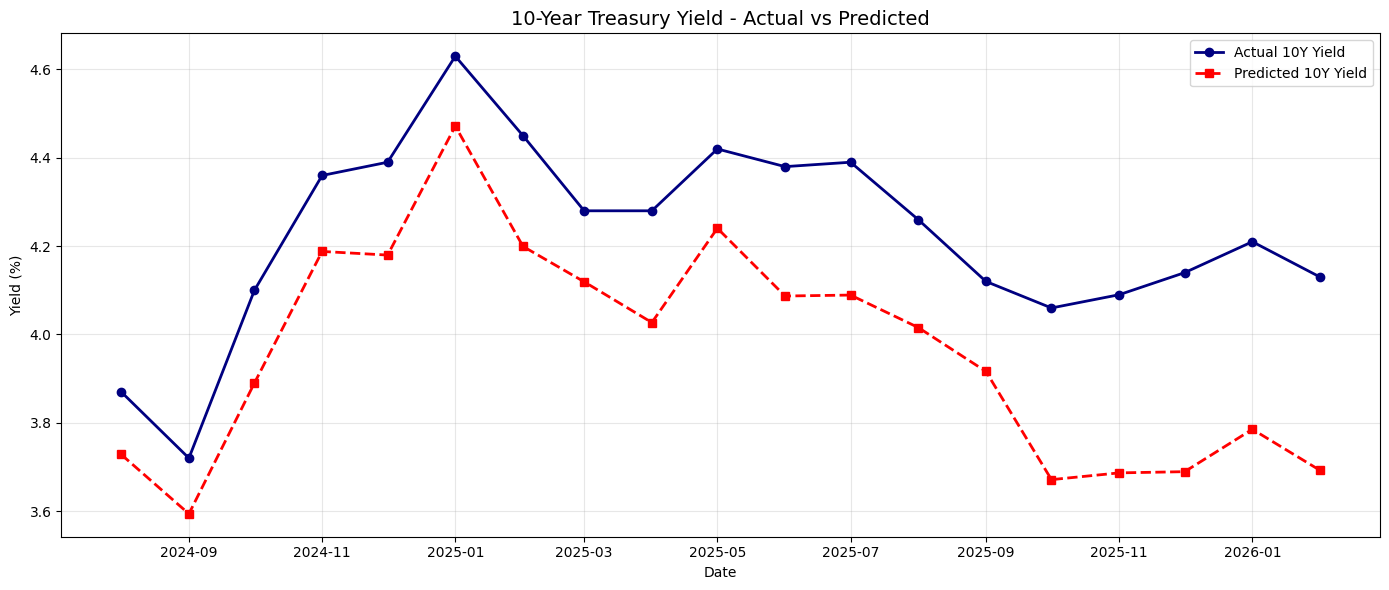

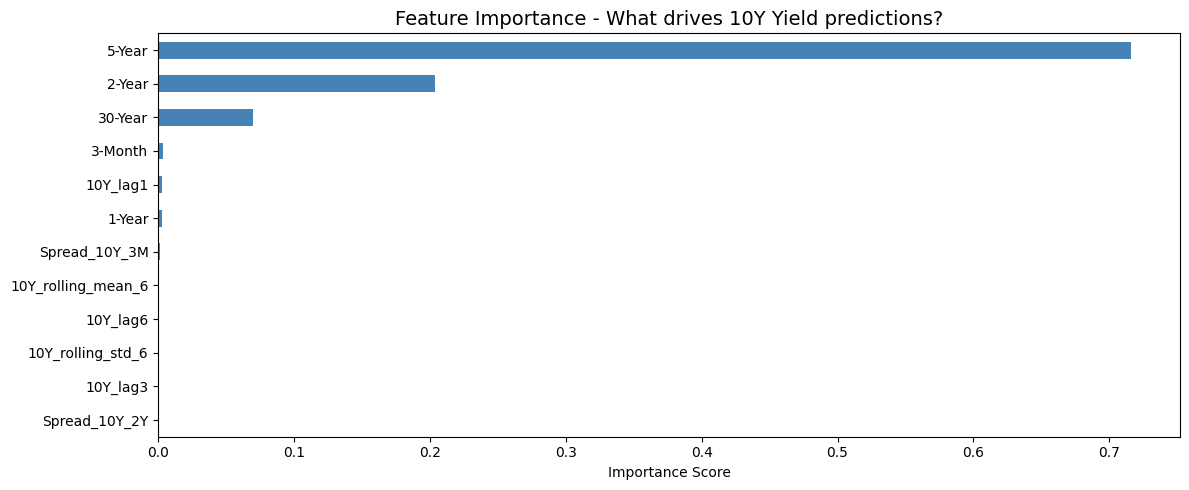

Charts saved!


In [ ]:
plt.figure(figsize=(14, 6))

# Plot actual vs predicted
plt.plot(y_test.index, y_test.values,
         color='navy', linewidth=2, label='Actual 10Y Yield', marker='o')
plt.plot(y_test.index, y_pred,
         color='red', linewidth=2, label='Predicted 10Y Yield',
         linestyle='--', marker='s')

plt.title('10-Year Treasury Yield - Actual vs Predicted', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

# Feature importance
plt.figure(figsize=(12, 5))
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - What drives 10Y Yield predictions?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Charts saved!")